In [1]:
# Import necessary libraries 
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2024-09-27 11:37:22.931174: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load the dataset
data = pd.read_csv('CTU-IoT-Malware-Capture-1.csv')

# Display the first few rows of the dataset
print(data.head())

# Check for missing values
print(data.isnull().sum())

           ts                 uid        id.orig_h  id.orig_p      id.resp_h  \
0  1538478770  CSQG794riQ4XnzTxP2  192.168.100.103      37082  192.168.100.1   
1  1538478780   COTbdG2BhtGBlmf6r  192.168.100.103      34486  192.168.100.1   
2  1538478790  CP48WJ2HOnLuGtr5kb  192.168.100.103      37601  192.168.100.1   
3  1538478780  CeTMJi2TydRSaVdsG4  192.168.100.103      46439  192.168.100.1   
4  1538478800  CZ6ne24AN9WAg9XA9d  192.168.100.103      55174  192.168.100.1   

   id.resp_p proto service  duration  orig_bytes  ...  local_resp  \
0         53   udp     dns  5.005151          78  ...           -   
1         53   udp     dns  0.007243          90  ...           -   
2         53   udp     dns  0.002250          90  ...           -   
3         53   udp     dns  5.005154          78  ...           -   
4         53   udp     dns  0.002246          90  ...           -   

  missed_bytes history orig_pkts  orig_ip_bytes resp_pkts  resp_ip_bytes  \
0            0       D      

In [3]:
# Inspect the DataFrame columns to find the target variable
print("Columns in the dataset:", data.columns)

# Set the features (X) and target variable (y)
X = data.drop(columns=['label'])  # Replace 'label' with the actual target column name
y = data['label']  # Ensure this is the correct target column

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Output the shapes of the features and target
print(f"Features shape: {X.shape}, Target shape: {y.shape}")

Columns in the dataset: Index(['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
       'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
       'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history',
       'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes',
       'tunnel_parents', 'label', 'detailed-label'],
      dtype='object')
Features shape: (153, 22), Target shape: (153,)


In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()  # Get categorical column names
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()    # Get numerical column names

# Create a column transformer to apply scaling and one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # One-hot encode categorical features
    ]
)

# Create a pipeline for preprocessing and PCA
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Apply preprocessor
    ('pca', PCA(n_components=0.95))  # Keep 95% of variance
])

# Fit and transform the training data, and transform the test data
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# Output the shapes of the transformed features
print(f"Transformed training features shape: {X_train_transformed.shape}")
print(f"Transformed testing features shape: {X_test_transformed.shape}")

Transformed training features shape: (122, 8)
Transformed testing features shape: (31, 8)


In [5]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_transformed, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_transformed)

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        31

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31

Confusion Matrix:
[[31]]


In [6]:
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers

# Assuming the target variable is in y_train and needs encoding
# Step 1: Convert categorical labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Transform y_train to numerical values
y_test_encoded = label_encoder.transform(y_test)  # Transform y_test

# Step 2: Define the deep learning model
dl_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile the model
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the model
history = dl_model.fit(X_train_transformed, y_train_encoded, epochs=20, validation_split=0.2)

# Make predictions
y_pred_dl = (dl_model.predict(X_test_transformed) > 0.5).astype("int32")

# If you want to decode predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred_dl.flatten())

# Check the predictions
print(y_pred_labels)

Epoch 1/20


2024-09-27 11:39:52.023521: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


4/4 [==============================] - 1s 51ms/step - loss: 0.7307 - accuracy: 0.5052 - val_loss: 0.6411 - val_accuracy: 0.6000
Epoch 2/20
4/4 [==============================] - 0s 10ms/step - loss: 0.6079 - accuracy: 0.7629 - val_loss: 0.5399 - val_accuracy: 0.8400
Epoch 3/20
4/4 [==============================] - 0s 8ms/step - loss: 0.5155 - accuracy: 0.8454 - val_loss: 0.4560 - val_accuracy: 1.0000
Epoch 4/20
4/4 [==============================] - 0s 8ms/step - loss: 0.4382 - accuracy: 0.9588 - val_loss: 0.3860 - val_accuracy: 1.0000
Epoch 5/20
4/4 [==============================] - 0s 9ms/step - loss: 0.3724 - accuracy: 1.0000 - val_loss: 0.3257 - val_accuracy: 1.0000
Epoch 6/20
4/4 [==============================] - 0s 9ms/step - loss: 0.3169 - accuracy: 1.0000 - val_loss: 0.2739 - val_accuracy: 1.0000
Epoch 7/20
4/4 [==============================] - 0s 7ms/step - loss: 0.2684 - accuracy: 1.0000 - val_loss: 0.2303 - val_accuracy: 1.0000
Epoch 8/20
4/4 [===========================

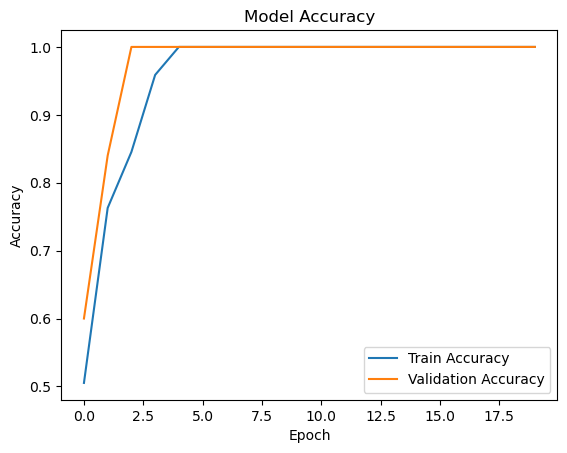

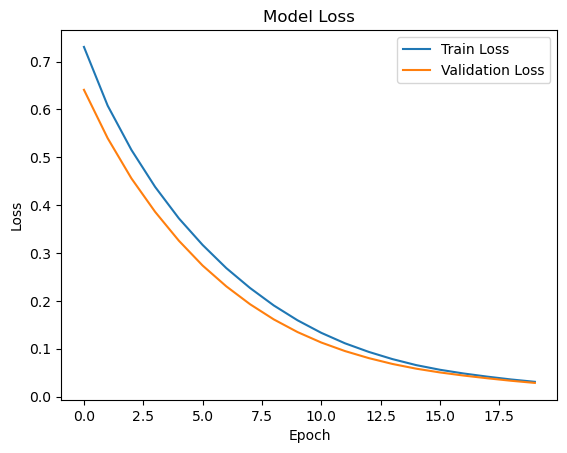

In [7]:
# Visualize the training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import classification_report

# Encode y_test before evaluation
y_test_encoded = label_encoder.transform(y_test)

# Convert predictions from Random Forest to numerical labels
y_pred_rf_encoded = label_encoder.transform(y_pred_rf)

print("Random Forest Model Metrics:")
print(classification_report(y_test_encoded, y_pred_rf_encoded))

print("Deep Learning Model Metrics:")
# Convert Deep Learning model predictions to binary (0 or 1)
y_pred_dl_binary = (y_pred_dl.flatten() > 0.5).astype(int)

# Map binary predictions back to original labels
# Assuming the mapping is 0 -> 'Benign' and 1 -> 'Malicious'
y_pred_dl_labels = np.array(['Benign' if pred == 0 else 'Malicious' for pred in y_pred_dl_binary])

print(classification_report(y_test, y_pred_dl_labels))

Random Forest Model Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31

Deep Learning Model Metrics:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        31

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31

